In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
df = pd.read_csv("IMDB_dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print(df.shape)
print(df['sentiment'].value_counts())

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Nanda Kishor V
[nltk_data]     A\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Nanda Kishor V
[nltk_data]     A\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Nanda Kishor V
[nltk_data]     A\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

In [7]:
df_small = df.head(1000)

df_small['clean_text'] = df_small['review'].apply(clean_text)

print(df_small[['review','clean_text']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                          clean_text  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  


C:\Users\Nanda Kishor V A\AppData\Local\Temp\ipykernel_29328\3807721386.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['clean_text'] = df_small['review'].apply(clean_text)


In [9]:
df['clean_text'] = df['review'].apply(clean_text)

In [11]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])

y = df['sentiment']

In [12]:
print(type(X))
print(X.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(50000, 5000)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [15]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [16]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [17]:
def evaluate(y_test, y_pred):
    return (
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    )

print("Logistic Regression:", evaluate(y_test, y_pred_lr))
print("Naive Bayes:", evaluate(y_test, y_pred_nb))
print("Decision Tree:", evaluate(y_test, y_pred_dt))

Logistic Regression: (0.888, 0.8882555705988981, 0.888, 0.8879681687337557)
Naive Bayes: (0.8548, 0.8548436521882425, 0.8548, 0.8547868015626671)
Decision Tree: (0.717, 0.717087249868282, 0.717, 0.7169999999999999)


In [18]:
print(y_pred_lr[:5])

['negative' 'positive' 'negative' 'positive' 'negative']


In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        evaluate(y_test, y_pred_lr)[0],
        evaluate(y_test, y_pred_nb)[0],
        evaluate(y_test, y_pred_dt)[0]
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression    0.8880
1          Naive Bayes    0.8548
2        Decision Tree    0.7170


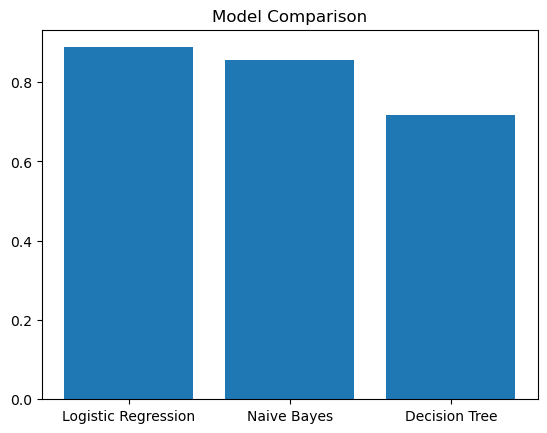

In [20]:
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.show()

In [21]:
def predict_sentiment(text):
    text = clean_text(text)
    vec = tfidf.transform([text])
    return lr.predict(vec)[0]

print(predict_sentiment("This movie is amazing"))

positive


## Conclusion

- Logistic Regression performed best
- TF-IDF improved accuracy
- Naive Bayes is fast but less accurate
- Decision Tree overfits

Preprocessing is very important in NLP.